# Mandelbrot Set - Numerical Scientific Computation

## Import Libraries

In [13]:
import numpy as np
from matplotlib import pyplot as plt
import time
import statistics

## Naive Python Implementation

### Computation of Singular Mandelbrot Point

In [ ]:
def mandelbrot_point(x, y, max_iterations, bound, power):
    c = complex(x, y)
    z = 0
    result = None

    for iteration in range(max_iterations):
        if(abs(z) >= bound):
            result = iteration
            break
        else:
            z = z**power + c
    else: # this is only called if the for loop never 'breaks'
        result = max_iterations

    return result

#### Testing the Naive Mandelbrot Point Function
Known points are extracted from image on Wikipedia: https://upload.wikimedia.org/wikipedia/commons/d/dc/Mandelbrot_set%2C_plotted_with_Matplotlib.svg.
The mandelbrot set is visualized using in pyplot, with the colormap parameter set to prism. The prism colormap, has the property of the rainbow pattern that consist of only 10 colors, repeatedly.

In [ ]:
# x_region = [-2, 1]
# y_region = [-1.5, 1.5]

max_iterations = 100
bound = 2
power = 2

known_points = [
    {'x':0, 'y':0, 'expected':100},
    {'x':-1.95, 'y':-0.6, 'expected':1},
    {'x':-1.85, 'y':-0.6, 'expected':2},
    {'x':-1.6, 'y':-0.5, 'expected':3},
    {'x':-1.0, 'y':-0.65, 'expected':4},
    {'x':-1.0, 'y':-0.5, 'expected':5},
    {'x':-0.85, 'y':-0.475, 'expected':6},
    {'x':-0.85, 'y':-0.4, 'expected':7},
    {'x':-0.775, 'y':-0.375, 'expected':8},
    {'x':-0.8, 'y':-0.325, 'expected':9}
]

print(f'{max_iterations=} | {power=}')
for point in known_points:
    x = point['x']
    y = point['y']
    expected = point['expected']

    result = mandelbrot_point(x, y, max_iterations, bound, power)

    print(f"{x=}, {y=} | {expected=} <-> {result=}")

max_iterations=100 | power=2
x=0, y=0 | expected=0 <-> result=0
x=-1.95, y=-0.6 | expected=1 <-> result=1
x=-1.85, y=-0.6 | expected=2 <-> result=2
x=-1.6, y=-0.5 | expected=3 <-> result=3
x=-1.0, y=-0.65 | expected=4 <-> result=4
x=-1.0, y=-0.5 | expected=5 <-> result=5
x=-0.85, y=-0.475 | expected=6 <-> result=6
x=-0.85, y=-0.4 | expected=7 <-> result=7
x=-0.775, y=-0.375 | expected=8 <-> result=8
x=-0.8, y=-0.325 | expected=9 <-> result=9


### Computing the Mandelbrot Grid

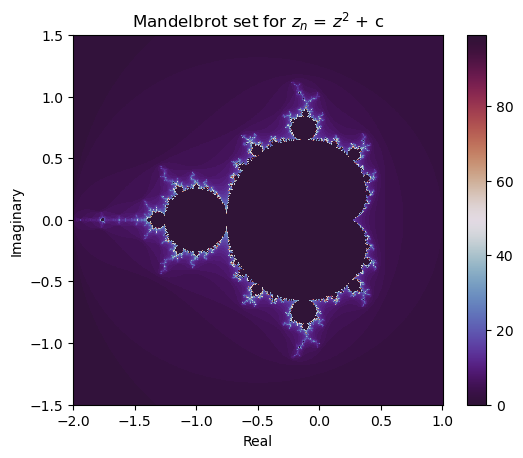

In [20]:
def compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power):
    mandelbrot_array = []

    for y_value in y_region:
        row = []
        for x_value in x_region:
            point_iteration = mandelbrot_point(x_value, y_value, max_iterations, bound, power)
            row.append(point_iteration)
        mandelbrot_array.append(row)

    return mandelbrot_array

# regions
x_min, x_max = -2, 1
y_min, y_max = -1.5, 1.5

x_res, y_res = 1024, 1024

x_region = np.linspace(x_min, x_max, x_res)
y_region = np.linspace(y_min, y_max, y_res)

max_iterations = 100
bound = 2
power = 2

mandelbrot_array = compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power)

ax = plt.axes()
ax.set_aspect('equal')
graph = ax.pcolormesh(x_region, y_region, mandelbrot_array, cmap = 'twilight_shifted')
plt.colorbar(graph)
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title('Mandelbrot set for $z_n$ = $z^2$ + c')
plt.show()

#### Testing the Naive Mandelbrot Grid Function

In [ ]:
def test_mandelbrot_grid():
    start_time = time.perf_counter()
    mandelbrot_array = compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power)
    test_time = time.perf_counter() - start_time
    print(f'Computation took {test_time:.3f} seconds!')
    return test_time

num_samples = 5
test_times = []

for sample in range(num_samples):
    test_time = test_mandelbrot_grid()
    test_times.append(test_time)

average_test_time = sum(test_times) / len(test_times)
print(f'Average computation time: {average_test_time:.4f} seconds!')

Computation took 3.294 seconds!
Computation took 3.312 seconds!
Computation took 3.352 seconds!
Computation took 3.233 seconds!
Computation took 3.199 seconds!
Average computation time: 3.278 seconds!


## Numpy Vectorization Implementation

### Computation of Numpy Vectorized Mandelbrot Grid

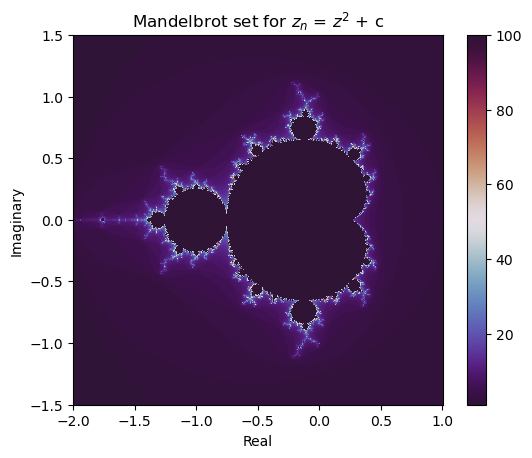

In [18]:
def compute_mandelbrot_mesh(x_region, y_region, max_iterations, bound, power):
    complex_number = 1j
    C = x_region + y_region * complex_number
    Z = np.zeros_like(C)
    M = np.zeros(C.shape, dtype=int)

    for _ in range(max_iterations):
        mask = np.abs(Z) <= bound
        Z[mask] = Z[mask]**power + C[mask]
        M[mask] += 1

    return M

# regions
x_min, x_max = -2, 1
y_min, y_max = -1.5, 1.5

x_res, y_res = 1024, 1024

x_values = np.linspace(x_min, x_max, x_res)
y_values = np.linspace(y_min, y_max, y_res)
x_region, y_region = np.meshgrid(x_values, y_values)

max_iterations = 100
bound = 2
power = 2

mandelbrot_array = compute_mandelbrot_mesh(x_region, y_region, max_iterations, bound, power)

ax = plt.axes()
ax.set_aspect('equal')
graph = ax.pcolormesh(x_region, y_region, mandelbrot_array, cmap = 'twilight_shifted')
plt.colorbar(graph)
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title(f'Mandelbrot set for $z_n$ = $z^{power}$ + c')
plt.show()


#### Testing Numpy Vectorized Mandelbrot Grid

In [ ]:
def test_mandelbrot_mesh():
    start_time = time.perf_counter()
    mandelbrot_array = compute_mandelbrot_mesh(x_region, y_region, max_iterations, bound, power)
    test_time = time.perf_counter() - start_time
    print(f'Computation took {test_time:.3f} seconds!')
    return test_time

num_samples = 5
test_times = []

for sample in range(num_samples):
    test_time = test_mandelbrot_mesh()
    test_times.append(test_time)

median_test_time = statistics.median(test_times)
print(f'Median computation time: {median_test_time:.4f} seconds!')

Computation took 1.389 seconds!
Computation took 1.259 seconds!
Computation took 1.401 seconds!
Computation took 1.349 seconds!
Computation took 1.265 seconds!
Median computation time: 1.349 seconds!
